In [ ]:
import numpy as np

In [ ]:
# 行列の定義
A = np.array([[1, 2],[-3, 4]])
print(A)

[[ 1  2]
 [-3  4]]


In [ ]:
# 転置行列と逆行列
B = A.T
C = np.linalg.inv(A)
print(B)
print(C)

[[ 1 -3]
 [ 2  4]]
[[ 0.4 -0.2]
 [ 0.3  0.1]]


In [ ]:
# 行列式、ランク
det_A = np.linalg.det(A)
rank_A = np.linalg.matrix_rank(A)
print('det_A=', det_A, 'rank_A=', rank_A)

det_A= 10.000000000000002 rank_A= 2


In [ ]:
# 固有値と固有ベクトル
e_val, e_vec = np.linalg.eig(A)
print('eigenvalue=', e_val)
print('eigenvector=', e_vec)

eigenvalue= [2.5+1.93649167j 2.5-1.93649167j]
eigenvector= [[0.38729833-0.5j 0.38729833+0.5j]
 [0.77459667+0.j  0.77459667-0.j ]]


In [ ]:
# ノルム
X = np.array([1, 2])
X_norm = np.linalg.norm(X)
print(X, 'norm=', X_norm)

[1 2] norm= 2.23606797749979


In [ ]:
# 数列を生成する
Td = np.arange(0, 20, 3)
print(Td)

[ 0  3  6  9 12 15 18]


In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

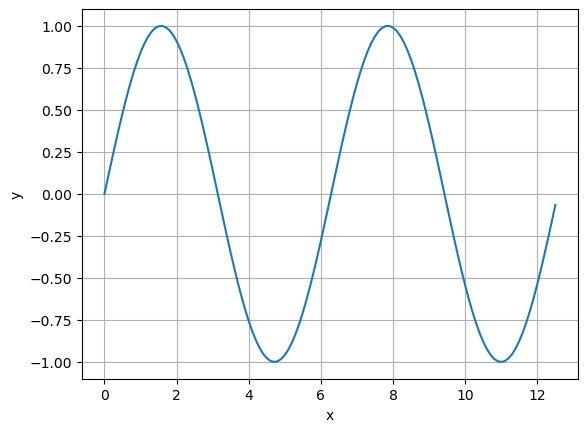

In [33]:
import numpy as np
x = np.arange(0, 4*np.pi, 0.1)
y = np.sin(x)
plt.plot(x, y) # Plot Graph
plt.xlabel('x') # x_axes label
plt.ylabel('y') # y_axes label
plt.grid()
plt.show()

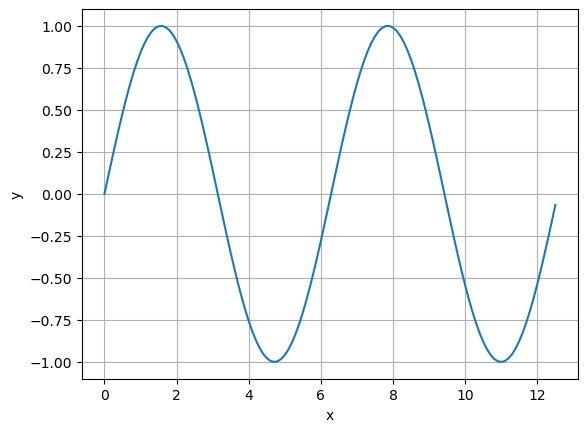

In [ ]:
# object oriented graph generation
fig, ax = plt.subplots()   # create fig, ax object
ax.plot(x, y)  # draw graph in ax object
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid()

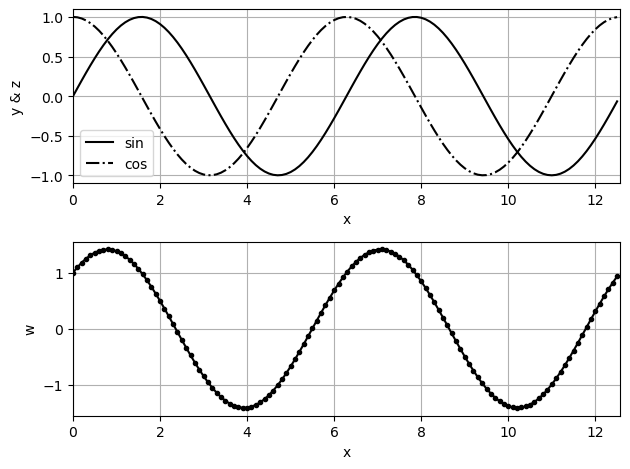

In [43]:
# 二つのグラフを表示する
fig, ax = plt.subplots(2,1)
x = np.arange(0, 4*np.pi, 0.1)
y = np.sin(x)
z = np.cos(x)
w = y + z

# create 1st graph
ax[0].plot(x, y, ls='-', label='sin', c='k')
ax[0].plot(x, z, ls='-.', label='cos', c='k')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y & z')
ax[0].set_xlim(0, 4*np.pi)
ax[0].grid()
ax[0].legend()

# create 2nd graph
ax[1].plot(x, w, color='k', marker='.')
ax[1].set_xlabel('x')
ax[1].set_ylabel('w')
ax[1].set_xlim(0, 4*np.pi)
ax[1].grid()

fig.tight_layout()

In [ ]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt

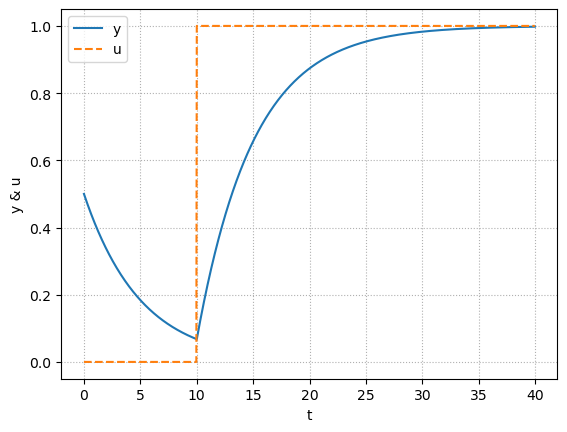

In [3]:
# 微分方程式の定義
def system(y, t):
    if t < 10.0:
        u = 0.0
    else:
        u = 1.0
    dydt = (-y + u) / 5.0
    return dydt

# 初期値と時間を設定して微分方程式を解く
y0 = 0.5
t = np.arange(0, 40, 0.04)
y = odeint(system, y0, t)

# グラフを描く
fig, ax = plt.subplots()
ax.plot(t, y, label='y')
ax.plot(t, 1*(t>=10), ls='--', label='u')
ax.set_xlabel('t')
ax.set_ylabel('y & u')
ax.legend(loc='best')
ax.grid(ls=':')

In [ ]:
import sympy as sp

In [ ]:
# 方程式の根を求める
sp.init_printing()  # LaTex形式出力
s = sp.Symbol('s')
root = sp.solve(2 * s**2 + 5*s + 3, s)
print(root)

[-3/2, -1]


In [ ]:
# 方程式の展開
func = sp.expand((s + 1)*(s + 2)**2, s)
print(func)

s**3 + 5*s**2 + 8*s + 4


In [ ]:
# 因数分解
g = sp.factor(func, s)
print(g)

(s + 1)*(s + 2)**2


In [1]:
import control

In [2]:
from control.matlab import *

In [3]:
Np = [0, 1]
Dp = [1, 2, 3]
P = tf(Np, Dp)
print(P)

<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


      1
-------------
s^2 + 2 s + 3



In [4]:
P = tf([0, 1], [1, 2, 3])
print(P)

<TransferFunction>: sys[1]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


      1
-------------
s^2 + 2 s + 3



In [5]:
P = tf([1, 2], [1, 5, 3, 4])
print(P)

<TransferFunction>: sys[2]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


        s + 2
---------------------
s^3 + 5 s^2 + 3 s + 4



In [6]:
Np = tf([1, 3], [0, 1])
Dp1 = tf([0, 1], [1, 1])
Dp2 = tf([0, 1], [1, 2])
P = Np * Dp1 * Dp2**2
print(P)

<TransferFunction>: sys[10]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


        s + 3
---------------------
s^3 + 5 s^2 + 8 s + 4



In [7]:
print(P.num)
print(P.den)

[[array([1, 3])]]
[[array([1, 5, 8, 4])]]


In [8]:
[[numP]], [[denP]] = tfdata(P)
print(numP)
print(denP)

[1 3]
[1 5 8 4]


In [12]:
# 状態空間モデル
A = [[0, 1], [-1, -1]]
B = [[0], [1]]
C = [[1, 0]]
D = [[0]]
P = ss(A, B, C, D)
print(P)

<StateSpace>: sys[11]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (2): ['x[0]', 'x[1]']

A = [[ 0.  1.]
     [-1. -1.]]

B = [[0.]
     [1.]]

C = [[1. 0.]]

D = [[0.]]



In [13]:
sysA, sysB, sysC, sysD = ssdata(P)
print(sysA)
print(sysB)
print(sysC)
print(sysD)

[[ 0.  1.]
 [-1. -1.]]
[[0.]
 [1.]]
[[1. 0.]]
[[0.]]


In [14]:
# システムの直列結合
S1 = tf([0, 1], [1, 1])
S2 = tf([1, 1], [1, 1, 1])
S = S1 * S2
print('S=', S)
S3 = series(S1, S2)
print('S3=',S3)

S= <TransferFunction>: sys[14]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


        s + 1
---------------------
s^3 + 2 s^2 + 2 s + 1

S3= <TransferFunction>: sys[15]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


        s + 1
---------------------
s^3 + 2 s^2 + 2 s + 1



In [15]:
# 並列結合
S = S1 + S2
print('S=', S)
S3 = parallel(S1, S2)
print('S3=', S3)


S= <TransferFunction>: sys[16]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


   2 s^2 + 3 s + 2
---------------------
s^3 + 2 s^2 + 2 s + 1

S3= <TransferFunction>: sys[17]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


   2 s^2 + 3 s + 2
---------------------
s^3 + 2 s^2 + 2 s + 1



In [16]:
# フィードバック結合
S = S1 / (1 + S1*S2)
print('S=', S)
S3 = feedback(S1, S2)
print('S3=', S3)

S= <TransferFunction>: sys[21]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


    s^3 + 2 s^2 + 2 s + 1
-----------------------------
s^4 + 3 s^3 + 5 s^2 + 5 s + 2

S3= <TransferFunction>: sys[22]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


     s^2 + s + 1
---------------------
s^3 + 2 s^2 + 3 s + 2



In [17]:
print('S=', S.minreal())

S= <TransferFunction>: sys[23]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


     s^2 + s + 1
---------------------
s^3 + 2 s^2 + 3 s + 2



In [18]:
S1 = tf(1, [1, 1])
S2 = tf(1, [1, 2])
S3 = tf([3, 1], [1, 0])
S4 = tf([2, 0], [0, 1])
S12 = feedback(S1, S2)
S123 = series(S12, S3)
S = feedback(S123, S4)
print('S=', S)

S= <TransferFunction>: sys[30]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


  3 s^2 + 7 s + 2
--------------------
7 s^3 + 17 s^2 + 7 s



In [19]:
P = tf([0, 1], [1, 1, 1])
Pss = tf2ss(P)
print('Pss=', Pss)
Ptf = ss2tf(Pss)
print('Ptf=', Ptf)

Pss= <StateSpace>: sys[31]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (2): ['x[0]', 'x[1]']

A = [[-1. -1.]
     [ 1.  0.]]

B = [[1.]
     [0.]]

C = [[0. 1.]]

D = [[0.]]

Ptf= <TransferFunction>: sys[33]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


     1
-----------
s^2 + s + 1



In [21]:
# 可制御正準形、可観測正準形
from control import canonical_form

A = [[1, 2, 3], [3, 2, 1], [4, 5, 0]]
B = [[1], [0], [1]]
C = [[0, 2, 1]]
D = [[0]]
Pss = ss(A, B, C, D)

Pr, T = canonical_form(Pss, form='reachable') # 可制御正準形
print(Pr)

<StateSpace>: sys[35]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (3): ['x[0]', 'x[1]', 'x[2]']

A = [[ 3. 21. 24.]
     [ 1.  0.  0.]
     [ 0.  1.  0.]]

B = [[1.]
     [0.]
     [0.]]

C = [[ 1.  9. 27.]]

D = [[0.]]



In [23]:
Po, T = canonical_form(Pss, form='observable') # 可観測正準形
print(Po)

<StateSpace>: sys[35]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (3): ['x[0]', 'x[1]', 'x[2]']

A = [[ 3.  1.  0.]
     [21.  0.  1.]
     [24.  0.  0.]]

B = [[ 1.]
     [ 9.]
     [27.]]

C = [[1. 0. 0.]]

D = [[0.]]



In [25]:
# グラフの線種を決めるジェネレータ関数
def linestyle_generator():
    linestyle = ['-', '--', '-.', ':']
    lineID = 0
    while True:
        yield linestyle[lineID]
        lineID = (lineID + 1) % len(linestyle)
        
# グラフを整える関数
def plot_set(fig_ax, *args):
    fig_ax.set_xlabel(args[0])
    fig_ax.set_ylabel(args[1])
    fig_ax.grid(ls=':')
    if len(args)==3:
        fig_ax.legend(loc=args[2])
        
# ボード線図を整える関数
def bodeplot_set(fig_ax, *args):
    # draw Gain
    fig_ax[0].grid(which="both", ls=':')
    fig_ax[0].set_ylabel('Gain [dB]')
    # draw Phase
    fig_ax[1].grid(which="both", ls=':')
    fig_ax[1].set_xlabel('Omega [rad/s]')
    fig_ax[1].set_ylabel('Phase [deg]')
    # 凡例の表示
    if len(args) > 0:
        fig_ax[0].legend(loc=args[0])
    if len(args) > 1:
        fig_ax[1].legend(loc=args[1])
    

In [26]:
# ステップ応答
from control.matlab import *
import matplotlib.pyplot as plt
import numpy as np

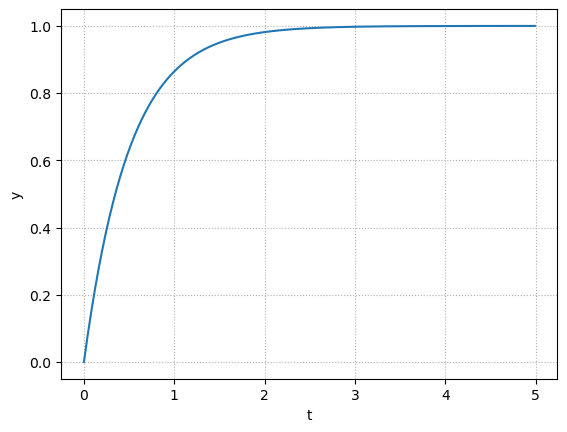

In [27]:
# 一次遅れ系のステップ応答
T, K = 0.5, 1 # Time Constant, Gain
P = tf([0, K], [T, 1])

y, t = step(P, np.arange(0, 5, 0.01))

fig, ax = plt.subplots()
ax.plot(t, y)
plot_set(ax, 't', 'y')

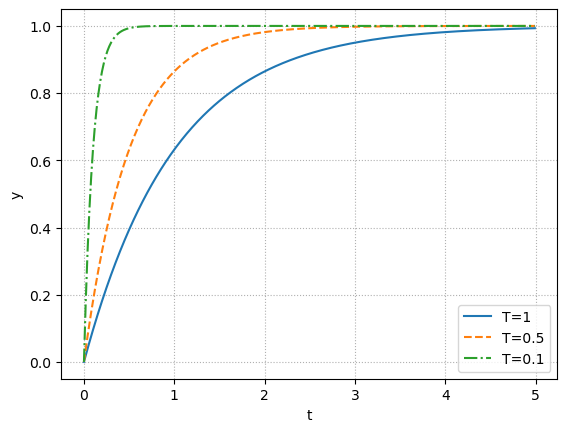

In [29]:
# 一次遅れ系の時定数を変化させる
fig, ax = plt.subplots()
LS = linestyle_generator()

K = 1
T = (1, 0.5, 0.1)
for i in range(len(T)):
    y, t = step(tf([0, K], [T[i], 1]), np.arange(0, 5, 0.01))
    ax.plot(t, y, ls = next(LS), label='T='+str(T[i]))
    
plot_set(ax, 't', 'y', 'best')

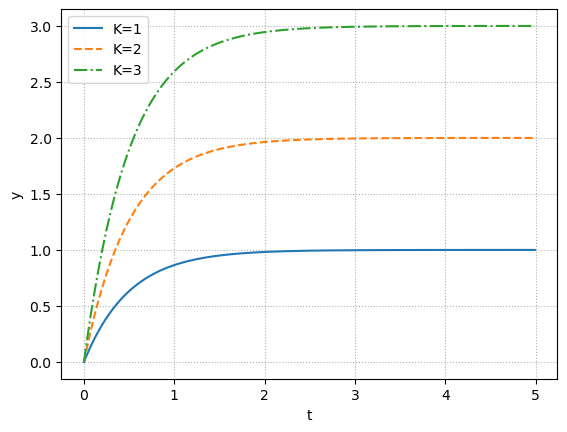

In [30]:
# 一次遅れ系のゲインKを変化させる
fig, ax = plt.subplots()
LS = linestyle_generator()

K = [1, 2, 3]
T = 0.5
for i in range(len(K)):
    y, t = step(tf([0, K[i]], [T, 1]), np.arange(0, 5, 0.01))
    ax.plot(t, y, ls = next(LS), label='K='+str(K[i]))
    
plot_set(ax, 't', 'y', 'upper left')

In [32]:
# 部分分数分解
import sympy as sp
sp.init_printing()
s = sp.Symbol('s')
T = sp.Symbol('T', real=True)
P = 1/((1 + T*s)*s)
sp.apart(P, s)

In [33]:
# 逆ラプラス変換
import sympy as sp
sp.init_printing()
s = sp.Symbol('s')
t = sp.Symbol('t', positive=True)
T = sp.Symbol('T', real=True)
sp.inverse_laplace_transform(1/s - 1/(s + 1/T), s, t)

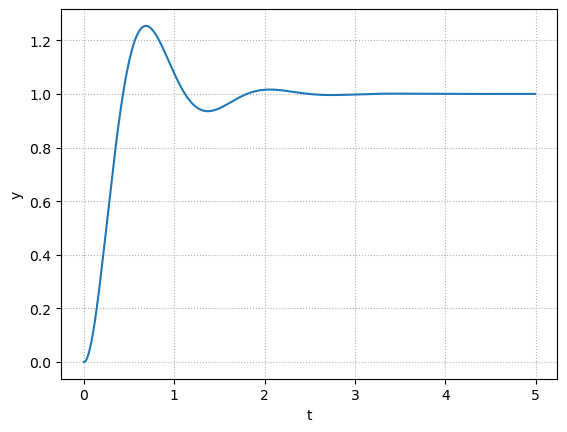

In [34]:
# 二次遅れ系のステップ応答
zeta, omega_n = 0.4, 5   # 減衰係数、固有角周波数

P = tf([0, omega_n**2], [1, 2*zeta*omega_n, omega_n**2])
y, t = step(P, np.arange(0, 5, 0.01))

fig, ax = plt.subplots()
ax.plot(t, y)
plot_set(ax, 't', 'y')

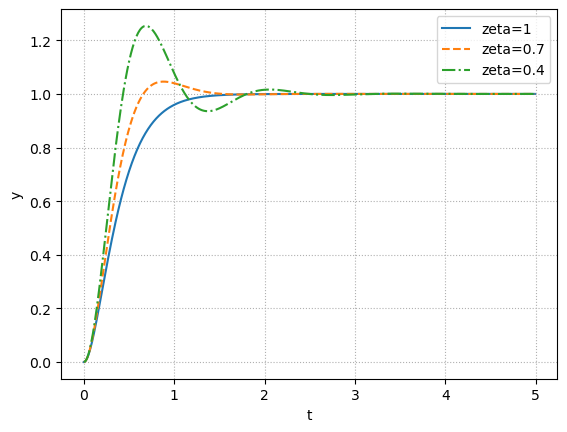

In [35]:
# 2次遅れ系の減衰係数を変化させたときのステップ応答
LS = linestyle_generator()
fig, ax = plt.subplots()

zeta = [1, 0.7, 0.4]
omega_n = 5
for i in range(len(zeta)):
    P = tf([0, omega_n**2], [1, 2*zeta[i]*omega_n, omega_n**2])
    y, t = step(P, np.arange(0, 5, 0.01))
    pltargs = {'ls': next(LS)}
    pltargs['label'] = 'zeta='+str(zeta[i])
    ax.plot(t, y, **pltargs)
    
plot_set(ax, 't', 'y', 'best')


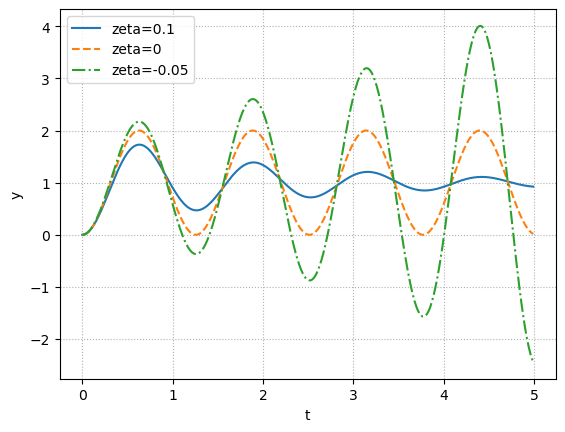

In [36]:
LS = linestyle_generator()
fig, ax = plt.subplots()

zeta = [0.1, 0, -0.05]
omega_n = 5
for i in range(len(zeta)):
    P = tf([0, omega_n**2], [1, 2*zeta[i]*omega_n, omega_n**2])
    y, t = step(P, np.arange(0, 5, 0.01))
    pltargs = {'ls': next(LS)}
    pltargs['label'] = 'zeta='+str(zeta[i])
    ax.plot(t, y, **pltargs)
    
plot_set(ax, 't', 'y', 'best')

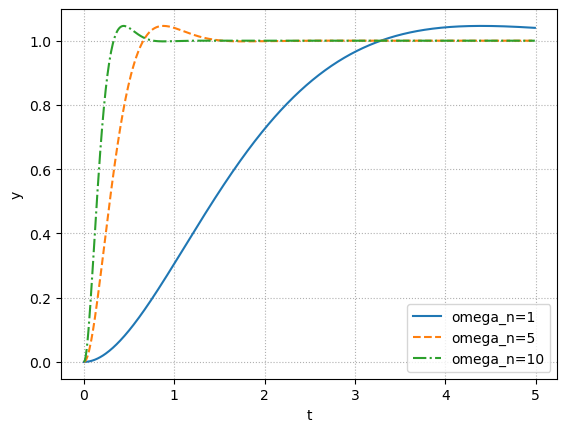

In [38]:
# 固有角周波数を変化させたときのステップ応答
LS = linestyle_generator()
fig, ax = plt.subplots()

zeta = 0.7
omega_n = [1, 5, 10]
for i in range(len(omega_n)):
    P = tf([0, omega_n[i]**2], [1, 2*zeta*omega_n[i], omega_n[i]**2])
    y, t = step(P, np.arange(0, 5, 0.01))
    pltargs = {'ls': next(LS)}
    pltargs['label'] = 'omega_n='+str(omega_n[i])
    ax.plot(t, y, **pltargs)
    
plot_set(ax, 't', 'y', 'best')

In [40]:
# 2次遅れ系の時間応答(zeta = 1 の場合)
import sympy as sp
sp.init_printing()
s = sp.Symbol('s')
t = sp.Symbol('t', positive=True)
w = sp.Symbol('w', real=True)
P = sp.apart(w**2/s/(s+w)**2, s)
sp.inverse_laplace_transform(P, s, t)

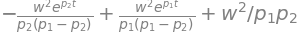

In [42]:
# zetaが１でない場合
p1 = sp.Symbol('p1', real=True)
p2 = sp.Symbol('p2', real=True)
P = sp.apart(w**2/(s*(s-p1)*(s-p2)), s)
sp.inverse_laplace_transform(P, s, t)

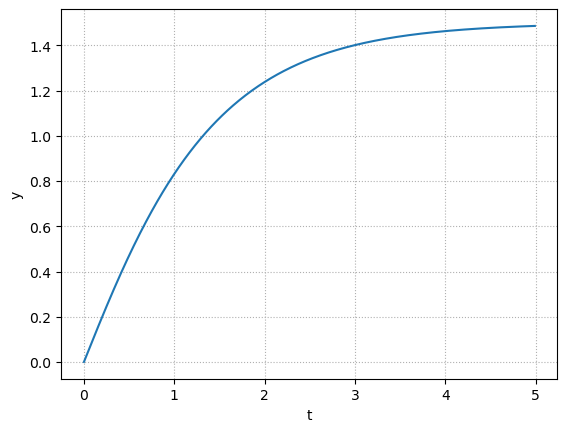

In [43]:
# example1
P = tf([1, 3], [1, 3, 2])
y, t = step(P, np.arange(0, 5, 0.01))

fig, ax = plt.subplots()
ax.plot(t, y)
plot_set(ax, 't', 'y')

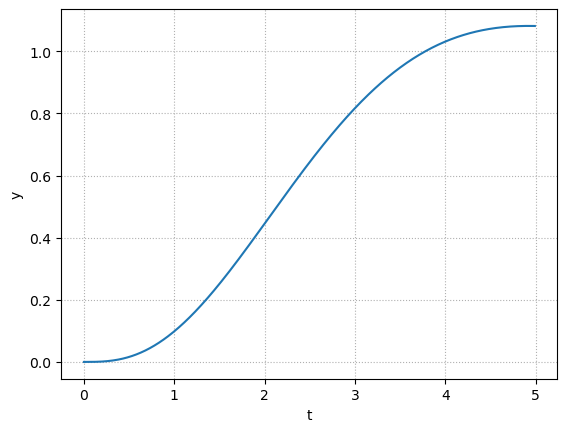

In [44]:
# example2
P = tf([0, 1], [1, 2, 2, 1])
y, t = step(P, np.arange(0, 5, 0.01))

fig, ax = plt.subplots()
ax.plot(t, y)
plot_set(ax, 't', 'y')